In [2]:
import numpy as np
import matplotlib.pyplot as plt

$y' = (1-x^2)y + F(x)$

4 варіант: $y = x \cdot cos(x)$

$y' = cos(x) - x \cdot sin(x)$

$cos(x) - x \cdot sin(x) = (1-x^2) \cdot x \cdot cos(x) + F(x)$  
$F(x) = cos(x) - x \cdot sin(x) - (1-x^2)\cdot x \cdot cos(x) $

$y' = (1-x^2)y + cos(x) - x \cdot sin(x) - (1-x^2)\cdot x \cdot cos(x) $

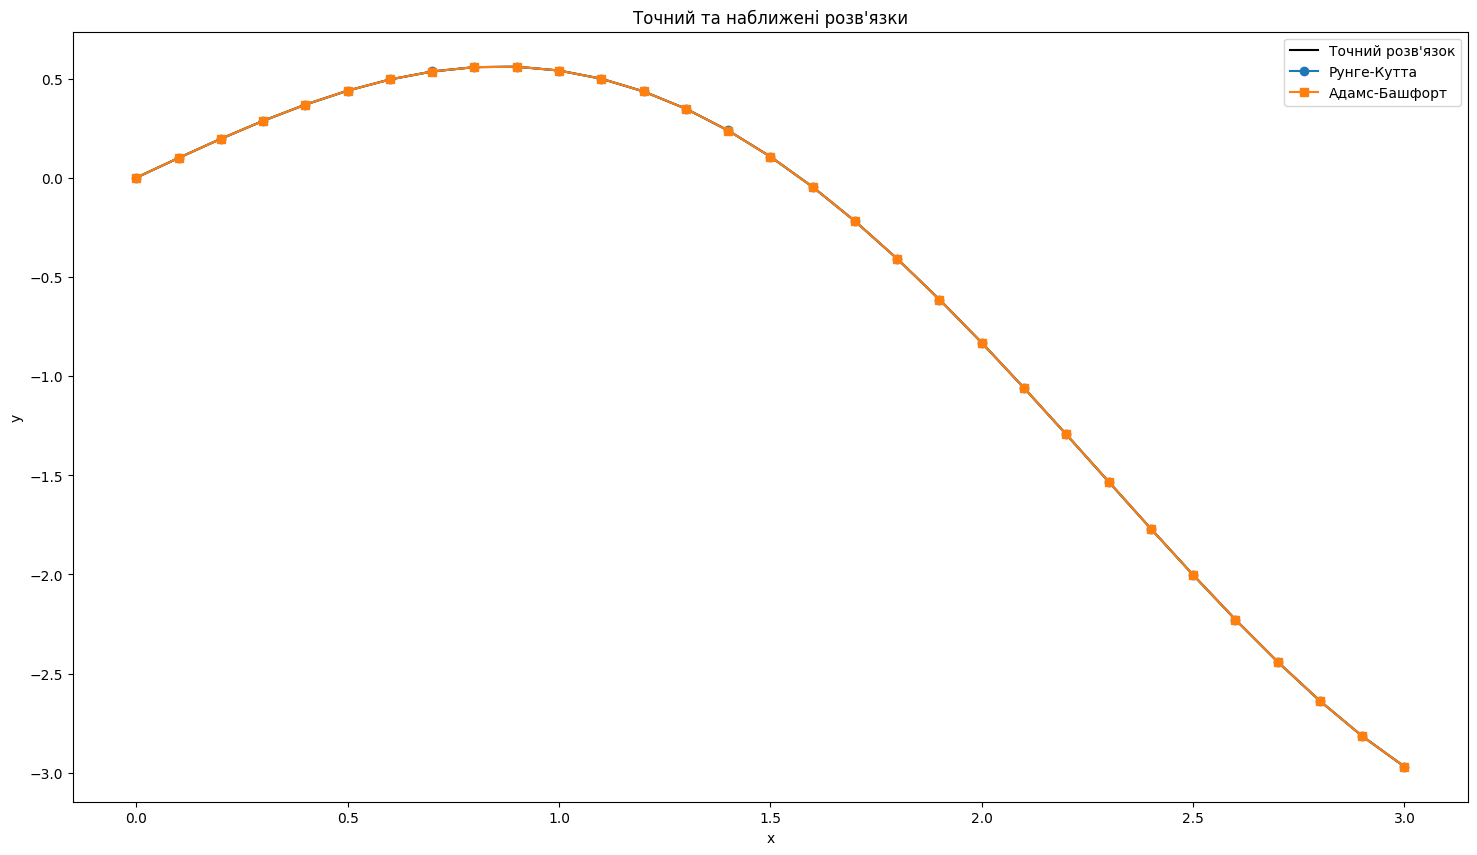

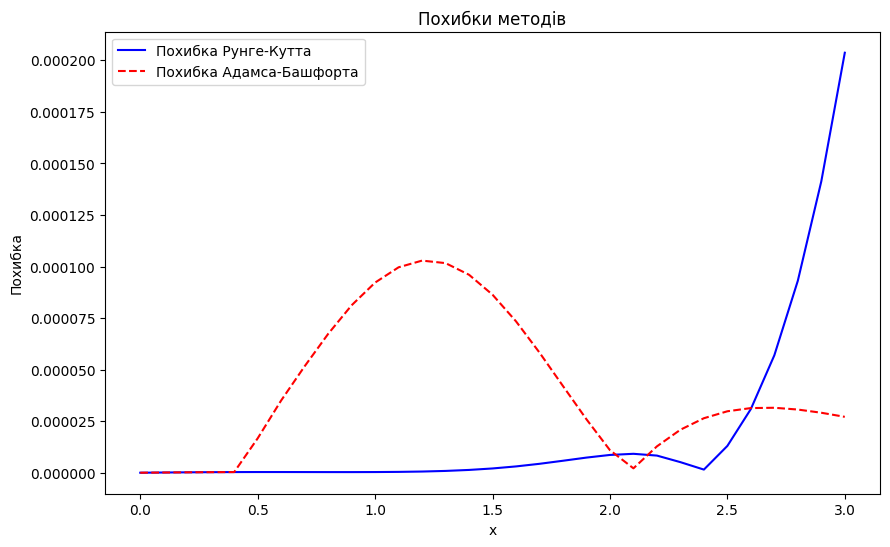

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Вихідні дані
h = 0.1
x0 = 0
y0 = 0
x_end = 3


def exact_solution(x):
    return x * np.cos(x)
# y'
def f(x, y):
    return (1 - x**2) * y + np.cos(x) - x * np.sin(x)-(1-x**2)*x*np.cos(x)


# Метод Рунге-Кутта четвертого порядку
def runge_kutta(x0, y0, h, x_end):
    x_values = [x0]
    y_values = [y0]
    x = x0
    y = y0
    while x <= x_end:
        k1 = h * f(x, y)
        k2 = h * f(x + h/2, y + k1/2)
        k3 = h * f(x + h/2, y + k2/2)
        k4 = h * f(x + h, y + k3)
        y += (k1 + 2 * k2 + 2 * k3 + k4) / 6
        x += h
        x_values.append(x)
        y_values.append(y)
    return np.array(x_values), np.array(y_values)

# Метод Адамса-Башфорта четвертого порядку
def adams_bashforth(x_values, y_values, h, x_end):
    while x_values[-1] < x_end:
        y_next = y_values[-1] + (h / 24) * (
            55 * f(x_values[-1], y_values[-1])
            - 59 * f(x_values[-2], y_values[-2])
            + 37 * f(x_values[-3], y_values[-3])
            - 9 * f(x_values[-4], y_values[-4])
        )
        x_next = x_values[-1] + h
        x_values = np.append(x_values, x_next)
        y_values = np.append(y_values, y_next)
    return x_values, y_values

# Розрахунок наближеного розв'язку
x_rk, y_rk = runge_kutta(x0, y0, h, x_end)

x_rk4, y_rk4 = runge_kutta(x0, y0, h, x0 + 3 * h)
x_ab, y_ab = adams_bashforth(x_rk4, y_rk4.copy(), h, x_end)

# Точний розв'язок
x_exact = np.linspace(x0, x_end, len(x_rk))
y_exact = exact_solution(x_exact)

# Графіки
plt.figure(figsize=(18, 10))
plt.plot(x_exact, y_exact, label="Точний розв'язок", linestyle='-', color='black')
plt.plot(x_rk, y_rk, 'o-', label='Рунге-Кутта')
plt.plot(x_ab, y_ab, 's-', label='Адамс-Башфорт')
plt.title("Точний та наближені розв'язки")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Графік похибки
plt.figure(figsize=(10, 6))
plt.plot(x_rk, np.abs(y_rk - y_exact), label='Похибка Рунге-Кутта', linestyle='-', color='blue')
plt.plot(x_ab, np.abs(y_ab - y_exact), label='Похибка Адамса-Башфорта', linestyle='--', color='red')
plt.title('Похибки методів')
plt.xlabel('x')
plt.ylabel('Похибка')
plt.legend()
plt.show()


In [75]:
y_rk - y_ab

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.63493567e-05,  3.47104087e-05,  5.13104879e-05,
        6.70151094e-05,  8.09046781e-05,  9.18872858e-05,  9.92195997e-05,
        1.02300397e-04,  1.00779658e-04,  9.46494324e-05,  8.42697123e-05,
        7.03584559e-05,  5.39351026e-05,  3.62296100e-05,  1.85751311e-05,
        2.30777916e-06, -1.13054045e-05, -2.10963893e-05, -2.59815461e-05,
       -2.49110968e-05, -1.67996198e-05, -4.57353806e-07,  2.54598534e-05,
        6.24704068e-05,  1.12251594e-04,  1.76591098e-04])